In [13]:
using Plots, LaTeXStrings, LsqFit
pgfplotsx()

Plots.PGFPlotsXBackend()

In [15]:
lin(x,p) = @. x*p[1]+p[2]
current = [
     0.25, 0.50, 0.75,
    1.00, 1.25, 1.50, 1.75,
    2.00, 2.25, 2.50, 2.75,
    3.00, 3.25, 3.50, 3.75
]

intensity = [
     0.20, 1.00, 2.40,
    4.30, 6.80, 10.00, 13.40,
    17.70, 22.40, 27.40, 33.30,
    39.60, 46.50, 53.60, 61.20
]

15-element Vector{Float64}:
  0.2
  1.0
  2.4
  4.3
  6.8
 10.0
 13.4
 17.7
 22.4
 27.4
 33.3
 39.6
 46.5
 53.6
 61.2

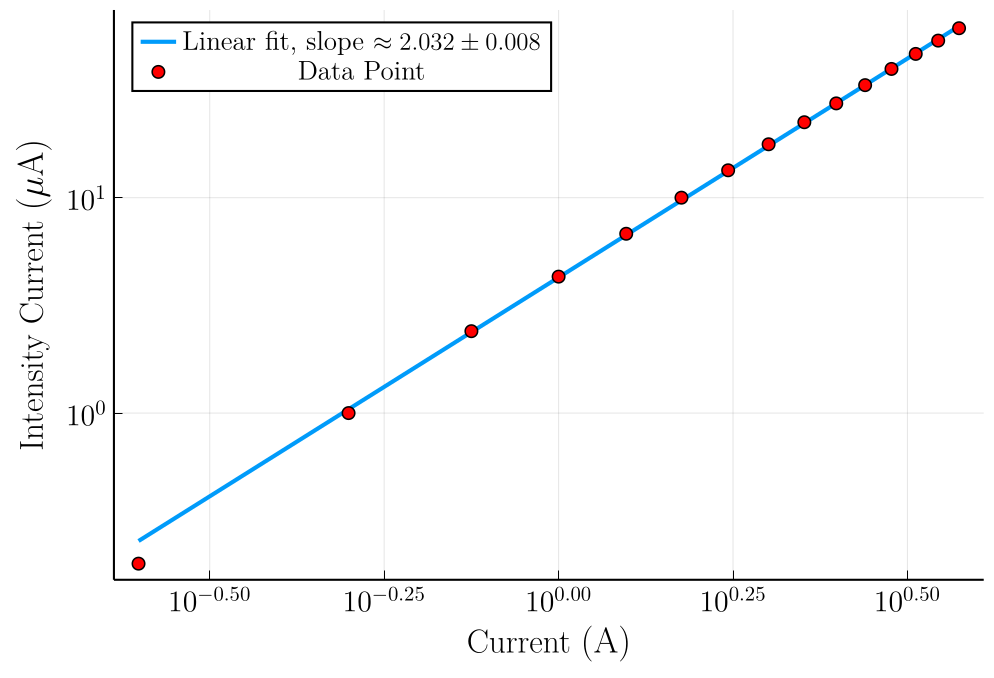

In [17]:
plot(current, (@. 10^inter*current^slope), lw=2, label=L"Linear fit, slope $\approx 2.032 \pm 0.008$", legendfontsize=13, tickfontsize=14, labelfontsize=16)
scatter!(current, intensity, marker=:circle, label="Data Point",xscale=:log10, yscale=:log10, c="red", size=(650,450), legend=:topleft)
xlabel!(L"Current $(\mathrm{A})$")

ylabel!(L"Intensity Current $(\mu \mathrm{A})$")


In [18]:
savefig("malus.pdf")

"/home/shaggy1304/IISER/IISER_Courses/PH4201/expt04/report/malus.pdf"

In [16]:
fiit = curve_fit(lin, log10.(current[2:end]),log10.(intensity[2:end]), [0.1,0.1])
slope, inter = fiit.param

2-element Vector{Float64}:
 2.0324339962679994
 0.6298463452123509

In [22]:
standard_errors(fiit)

2-element Vector{Float64}:
 0.008319421834755595
 0.0030542494936806512

In [21]:
H = [
    0.00, 131.25, 262.50, 393.76,
    525.01, 656.26, 787.51, 918.76,
    1050.02, 1181.27, 1312.52, 1443.77,
    1575.02, 1706.28, 1837.53, 1968.78
]

theta = [
    0.00, 30.00, 72.00, 102.00,
    132.00, 162.00, 204.00, 246.00,
    276.00, 294.00, 330.00, 384.00,
    414.00, 450.00, 480.00, 498.00
];

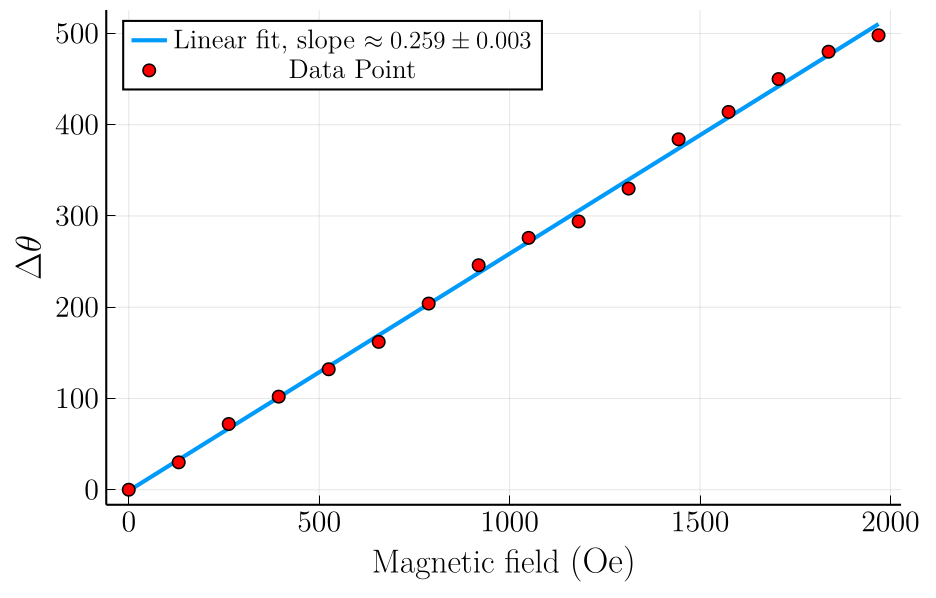

In [30]:
pgfplotsx()
plot(H, lin(H,fiit.param), lw=2, label=L"Linear fit, slope $\approx 0.259 \pm 0.003$", legendfontsize=13, tickfontsize=14, labelfontsize=16)
scatter!(H,theta, c="red", lw=2, label="Data Point", legendfontsize=13, tickfontsize=14, labelfontsize=16)
xlabel!(L"Magnetic field $(\mathrm{Oe})$")
ylabel!(L"$\Delta\theta$", legend=:topleft)

In [31]:
savefig("verdet.pdf")

"/home/shaggy1304/IISER/IISER_Courses/PH4201/expt04/report/verdet.pdf"

In [22]:
fiit = curve_fit(lin, H,theta, [0.1,0.1])
slope, inter = fiit.param

2-element Vector{Float64}:
  0.25982778804218326
 -1.1468762710247202

In [23]:
standard_errors(fiit)

2-element Vector{Float64}:
 0.0031042256135179955
 3.5868245929332474